# Particle Localization and Phase Mask Optimization

This tutorial demonstrates how to jointly optimize an optical phase mask and a neural network to improve the localization of closely spaced particles in microscopy images.

The phase mask, inserted in the optical pupil plane, shapes the microscope’s point spread function (PSF). Simultaneously, a convolutional neural network (CNN) is trained to reconstruct the 3D particle positions from simulated images. Through backpropagation, gradients flow not only through the network but also through the optical model. As a result, the optical system learns to produce images that are easier for the CNN to interpret, leading to improved localization accuracy.

# 1. Create a simulation pipeline
The first step is to define a simulation pipeline that generates synthetic data consisting of fluorescent particles imaged through a fluorescence microscope. For each simulated image, the pipeline also provides the true 3D positions of the particles, which serve as the ground truth during training.

In [ ]:
import deeptrack as dt

from lightning.pytorch import seed_everything
seed_everything(100, workers=True);

Seed set to 100


## 1.1 Set the backend
DeepTrack supports both NumPy and PyTorch backends. In this tutorial, the PyTorch backend is selected to enable backpropagation through the optical setup. Enabling CUDA (optional) allows the computations to run on the GPU, which accelerates both simulation and training.

In [2]:
from deeptrack.backend import config

config.set_backend("torch")
config.set_device("cuda")

device = config.get_device()

print(config.get_backend(), config.get_device())

torch cuda


## 1.2 Define the trainable phase mask
A phase mask modifies the wavefront of light in the microscope pupil plane, shaping the resulting point spread function (PSF). By making the phase mask trainable, we allow the optical system itself to learn — optimizing its design through gradient descent to improve particle localization performance.

The LearnablePhaseMask class inherits from both `nn.Module` and `dt.Aberration`. `nn.Module` makes the phase mask compatible with PyTorch’s autograd and optimizer system, allowing the phase mask parameters to be learned, while `dt.Aberration` ensures the class integrates seamlessly into DeepTrack’s feature graph, making it compatible with the rest of the optical pipeline.

In [3]:
import torch
import torch.nn as nn


class LearnablePhaseMask(nn.Module, dt.Aberration):
    """Applies a learnable phase mask to the pupil function."""

    def __init__(self, shape=(144, 144), **kwargs):
        dt.Aberration.__init__(self, **kwargs)
        super().__init__(**kwargs)

        # Trainable phase mask parameter
        self.phase = nn.Parameter(torch.zeros(shape, dtype=torch.float32))

    def forward(self, pupil: torch.Tensor, **kwargs) -> torch.Tensor:
        """PyTorch forward pass for use in training"""
        return self.apply_phase(pupil)

    def get(self, pupil: torch.Tensor, **kwargs) -> torch.Tensor:
        """DeepTrack Feature graph call"""
        return self.apply_phase(pupil)

    def apply_phase(self, pupil: torch.Tensor) -> torch.Tensor:
        """Shared implementation of phase modulation"""
        phase = self.phase.to(device)
        phase_mask = torch.cos(phase) + 1j * torch.sin(phase)
        return pupil * phase_mask

## 1.3 Define the optical setup
The optical setup is simulated using `dt.Fluorescence`, incorporating the trainable phase mask as the pupil function.

In [4]:
image_size = 121
depth = 30  # Number of axial slices (z-planes)

In [5]:
phase_mask = LearnablePhaseMask()

optics = dt.Fluorescence(
    NA=1.45,
    refractive_index_medium=1.33,
    output_region=(0, 0, image_size, image_size),
    pupil=phase_mask,
)

## 1.4 Simulate particles
A simulation pipeline is defined to generate images of randomly positioned 3D particles, together with their corresponding ground-truth localization targets.

A custom DeepTrack feature, `Positions`, creates a binary 3D mask containing randomly placed particles. Each voxel corresponding to a particle is assigned a value of 1, while background voxels remain 0. The true particle coordinates are stored in self.points for later retrieval.

In [6]:
class Positions(dt.Feature):
    def get(self, image, num_points, **kwargs):
        mask = torch.zeros(
            (image.shape[0], image.shape[1], image.shape[2]), dtype=float
        )

        points = torch.rand(size=(num_points, 3)) * torch.tensor(image.shape)

        for i in range(len(points)):
            mask[
                torch.round(points[i, 0]).long().clamp(0, image.shape[0] - 1),
                torch.round(points[i, 1]).long().clamp(0, image.shape[1] - 1),
                torch.round(points[i, 2]).long().clamp(0, image.shape[2] - 1),
            ] = 1

        self.points = points

        return mask + image

The number of points for each sample is randomized between 25 and 50 to provide diverse training examples.

In [7]:
num_points = lambda: int(torch.randint(low=25, high=50, size=(1,)))
xyz = Positions(num_points=num_points)

To make the training data physically plausible, a combination of Poisson noise and Gaussian noise is added.

Since true Poisson noise is not differentiable, a Gaussian approximation that preserves differentiability during backpropagation is used.

In [8]:
class poisson_noise_approx(dt.Noise):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def get(self, image, noise_scale=1e-2, **kwargs):

        image = torch.clamp(image, min=0.0)

        # Gaussian approximation of Poisson noise
        noise = torch.sqrt(image) * torch.randn_like(image, device=self.device)
        noisy_image = image + noise * noise_scale

        return noisy_image

Next, the components, including the particle positions, the optics, and the noise, are combined to form the simulation pipeline.

In [9]:
i = -1


def next_position():
    global i
    gt_pip.resolve()
    i = (i + 1) % len(xyz.points)
    return xyz.points[i]


particle = dt.PointParticle(position=next_position, intensity=100)

gt_pip = (
    dt.Value(torch.zeros((image_size, image_size, depth), dtype=float)) >> xyz
)

noise_gaussian = dt.Gaussian(
    mu=0, sigma=lambda: torch.rand(size=(1,), device=device) * 1e-4
)
noise_poisson = poisson_noise_approx(
    noise_scale=lambda: torch.rand(size=(1,), device=device) * 1e-2
)

im_pip = optics(particle ^ num_points) >> noise_poisson >> noise_gaussian

pip = (im_pip & gt_pip) >> dt.MoveAxis(2, 0)

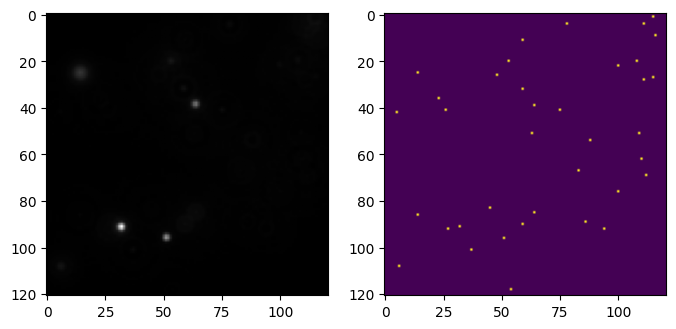

In [10]:
import matplotlib.pyplot as plt

pip.update()
im, gt = pip.resolve()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(im[0].cpu().detach().numpy(), cmap="gray")
axs[1].imshow(gt.max(dim=0)[0]);

## 2. Defining the CNN
A convolutional neural network (CNN) is used to reconstruct a 3D probability volume of particle positions from a single 2D microscopy image. The network outputs one channel per axial plane, corresponding to the likelihood of a particle at each depth.

### 2.1 Architecture
The custom class `CNNConcat` extends a standard convolutional neural network by allowing each intermediate layer receive both the original input and the features from the previous layer.

In [11]:
import deeplay as dl


class CNNConcat(dl.ConvolutionalNeuralNetwork):
    def forward(self, input):
        out = None

        for idx, block in enumerate(self.blocks):

            if idx == 0:
                out = block(input)

            elif idx < len(self.blocks) - 1:
                features = torch.cat((out, input), dim=1)
                new_out = block(features)
                out = new_out + out

            else:
                out = block(out)

        return out

In [12]:
hidden_dim = 64
factor = 10.0

CNN = CNNConcat(
    in_channels=1,
    hidden_channels=[hidden_dim + 1] * 8 + [hidden_dim],
    out_channels=depth,
)

CNN["blocks", "0"].prepend(
    dl.Layer(torch.nn.BatchNorm2d, num_features=1),
    name="initial_normalization",
)
CNN[..., "activation"].all.configure(
    nn.LeakyReLU, negative_slope=0.2, inplace=True
)
CNN[...].isinstance(dl.Conv2dBlock).all.normalized(torch.nn.BatchNorm2d)
CNN[..., "normalization"].all.configure(num_features=hidden_dim)

CNN[..., "layer#:-1"].configure(out_channels=hidden_dim)

CNN["blocks", "9", "layer"].configure(kernel_size=1, padding=0)
CNN["blocks", "9"].remove("normalization", allow_missing=True)
CNN[..., "activation#-1"].configure(nn.Hardtanh, min_val=0.0, max_val=factor);

In [13]:
cnn = CNN.create()

cnn.to(device)
print(cnn)

CNNConcat(
  (blocks): LayerList(
    (0): Conv2dBlock(
      (initial_normalization): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (layer): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.2, inplace=True)
      (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1-8): 8 x Conv2dBlock(
      (layer): Conv2d(65, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.2, inplace=True)
      (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (9): Conv2dBlock(
      (layer): Conv2d(64, 30, kernel_size=(1, 1), stride=(1, 1))
      (activation): Hardtanh(min_val=0.0, max_val=10.0, inplace=True)
    )
  )
)


Check that the outputs of the cnn and the targets have the same shape:

In [14]:
images, gt = [], []
for _ in range(2):
    pip.update()
    img, g = pip.resolve()
    images.append(img)
    gt.append(g)

images = torch.stack(images).to(device, dtype=torch.float32)
gt = torch.stack(gt).to(device, dtype=torch.float32)

cnn.eval()
preds = cnn(images)
print("Preds:", preds.shape)
print("Target:", gt.shape)

Preds: torch.Size([2, 30, 121, 121])
Target: torch.Size([2, 30, 121, 121])


### 2.2 Loss function
Training minimizes a combination of a 3D kernel density loss and a Dice loss, adapted from [DeepSTORM-3D](https://www.nature.com/articles/s41592-020-0853-5).

The KDE term compares Gaussian-smoothed versions of prediction and ground truth, providing robustness to small spatial shifts. The Dice term measures voxel-wise overlap, encouraging sparsity and accurate localization.

In [15]:
import numpy as np
import torch.nn.functional as F


def dice_loss(pred, target):
    """
    This definition generalize to real valued pred and target vector.
    pred: tensor with first dimension as batch
    target: tensor with first dimension as batch
    """

    smooth = 1.0

    # have to use contiguous since they may from a torch.view op
    iflat = pred.contiguous().view(-1)
    tflat = target.contiguous().view(-1)
    intersection = (iflat * tflat).sum()

    A_sum = torch.sum(iflat * iflat)
    B_sum = torch.sum(tflat * tflat)

    return 1 - ((2.0 * intersection + smooth) / (A_sum + B_sum + smooth))


# create a 3D gaussian kernel
def GaussianKernel(shape=(3, 3, 3), sigma=0.1, normfactor=1):
    """
    3D gaussian mask - should give the same result as MATLAB's
    fspecial('gaussian',[shape],[sigma]) in 3D
    """
    m, n, p = [(ss - 1.0) / 2.0 for ss in shape]
    y, x, z = np.ogrid[-m : m + 1, -n : n + 1, -p : p + 1]
    h = np.exp(-(x * x + y * y + z * z) / (2 * sigma**2))
    h[h < np.finfo(h.dtype).eps * h.max()] = 0
    """
    sumh = h.sum()
    if sumh != 0:
        h /= sumh
        h = h * normfactor
    """
    maxh = h.max()
    if maxh != 0:
        h /= maxh
        h = h * normfactor
    h = torch.from_numpy(h).type(torch.FloatTensor)
    h = h.unsqueeze(0)
    h = h.unsqueeze(1)
    return h


# define the 3D extended loss function from DeepSTORM
class KDE_loss3D(nn.Module):
    def __init__(self, factor, device):
        super(KDE_loss3D, self).__init__()
        self.kernel = GaussianKernel().to(device)
        self.factor = factor

    def forward(self, pred_bol, target_bol):

        # extract kernel dimensions
        N, C, D, H, W = self.kernel.size()

        # extend prediction and target to have a single channel
        target_bol = target_bol.unsqueeze(1)
        pred_bol = pred_bol.unsqueeze(1)

        # KDE for both input and ground truth spikes
        Din = F.conv3d(
            pred_bol, self.kernel, padding=(int(np.round((D - 1) / 2)), 0, 0)
        )
        Dtar = F.conv3d(
            target_bol,
            self.factor * self.kernel,
            padding=(int(np.round((D - 1) / 2)), 0, 0),
        )

        kde_loss = nn.MSELoss()(Din, Dtar)

        # final loss
        final_loss = kde_loss + dice_loss(pred_bol / self.factor, target_bol)

        return final_loss

In [16]:
loss_fn = KDE_loss3D(factor=factor, device=device)

### 2.3 Joint optimization
The CNN and the learnable phase mask are optimized together using the Adam optimizer.
Gradients propagate through both the network and the optical model, allowing the phase mask to adapt so that the simulated images become more informative for localization.

In [17]:
optimizer = torch.optim.Adam(
    list(phase_mask.parameters()) + list(cnn.parameters()), lr=1e-3
)

## 3. Training the CNN and the phase mask
### 3.1 Visualize the phase mask before training
Before starting the optimization, the initial phase mask can be inspected to verify its values and distribution. At this stage, all phase values are zero, corresponding to an untrained, flat wavefront.

Phase mask statistics — min: 0.0 max: 0.0 mean: 0.0


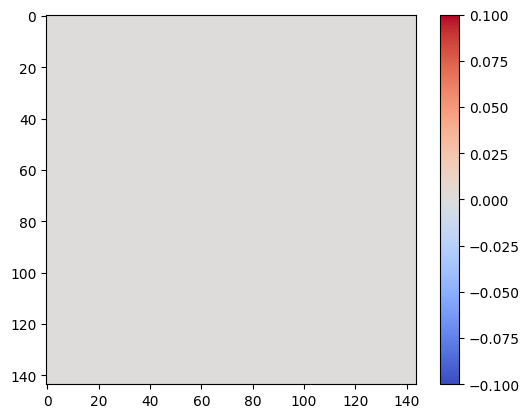

In [18]:
phase_mask_before = phase_mask.phase.cpu().detach().clone()
print(
    "Phase mask statistics — min:", phase_mask.phase.min().item(),
    "max:", phase_mask.phase.max().item(),
    "mean:", phase_mask.phase.mean().item(),
)

plt.imshow(phase_mask_before, cmap="coolwarm")
plt.colorbar()
plt.show()

### 3.2 Joint training of the CNN and the phase mask

The CNN and the phase mask are trained jointly using a custom training loop.

Because the simulated images depend on the current phase mask, the simulation pipeline must be updated each epoch. This ensures that new image batches reflect the latest state of the optical system. If the dataset were generated only once before training, all images would correspond to the untrained phase mask, and the phase mask would not receive meaningful gradient updates.

For each epoch, a new batch of synthetic images and their ground-truth particle positions is generated. The loss is then computed and backpropagated, updating both the CNN and the phase mask parameters.

In [19]:
num_epochs = 1000
batch_size = 10
loss_history = []

for epoch in range(num_epochs):
    cnn.train()

    images, gt = [], []
    for _ in range(batch_size):
        pip.update()
        img, g = pip.resolve()
        images.append(img)
        gt.append(g)

    images = torch.stack(images).to(device, dtype=torch.float32)
    gt = torch.stack(gt).to(device, dtype=torch.float32)

    optimizer.zero_grad(set_to_none=True)
    preds = cnn(images)
    loss = loss_fn(preds, gt)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.detach().cpu().item())

    if (epoch % 50) == 0:
        print(f"Epoch {epoch}, Loss: {loss.detach().cpu().item():.4f}")

Epoch 0, Loss: 2.0495
Epoch 50, Loss: 0.8656
Epoch 100, Loss: 0.7788
Epoch 150, Loss: 0.7115
Epoch 200, Loss: 0.6595
Epoch 250, Loss: 0.6279
Epoch 300, Loss: 0.5539
Epoch 350, Loss: 0.5374
Epoch 400, Loss: 0.5098
Epoch 450, Loss: 0.5039
Epoch 500, Loss: 0.4845
Epoch 550, Loss: 0.4807
Epoch 600, Loss: 0.4696
Epoch 650, Loss: 0.4511
Epoch 700, Loss: 0.4718
Epoch 750, Loss: 0.4672
Epoch 800, Loss: 0.4702
Epoch 850, Loss: 0.4426
Epoch 900, Loss: 0.4701
Epoch 950, Loss: 0.4673


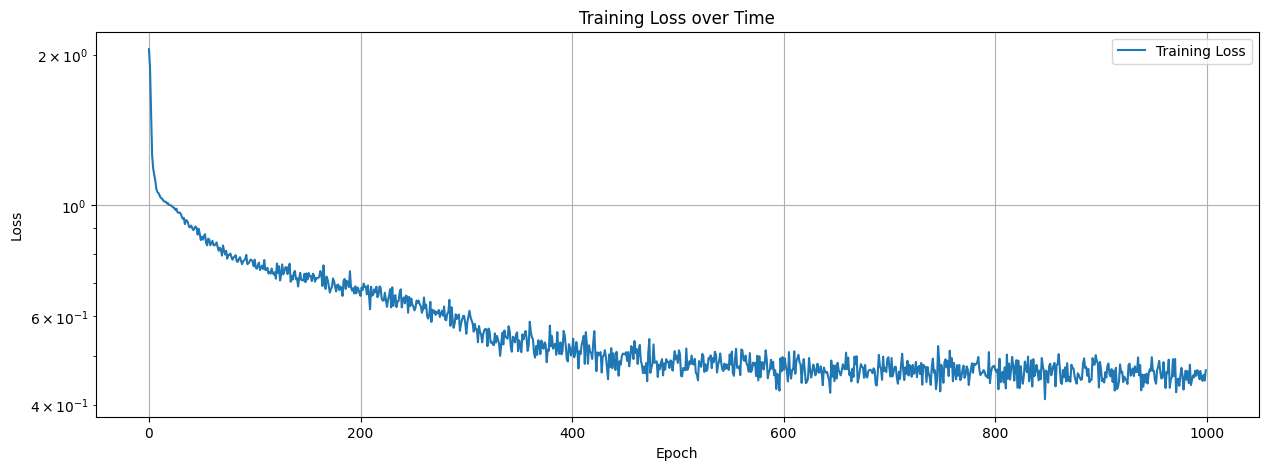

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(range(len(loss_history)), loss_history, label="Training Loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.grid(True)
plt.legend()
plt.show()

### 3.3 Visualize the phase mask after training
After training, the optimized phase mask can be visualized. Comparing the initial and final phase masks provides insight into how the learning process has adapted the optical system.

Phase mask stats — min: -0.613, max: 0.666, mean: 0.000


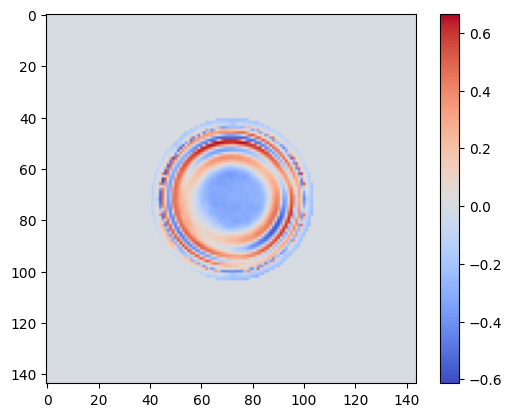

In [21]:
phase_mask_after = phase_mask.phase.cpu().detach().clone()
print(
    f"Phase mask stats — min: {phase_mask.phase.min():.3f}, "
    f"max: {phase_mask.phase.max():.3f}, "
    f"mean: {phase_mask.phase.mean():.3f}"
)

plt.imshow(phase_mask_after, cmap="coolwarm")
plt.colorbar()
plt.show()

## 4. Post-processing
The post-processing module, adapted from [DeepSTORM3D](https://www.nature.com/articles/s41592-020-0853-5), converts the network’s 3D confidence volume into discrete particle coordinates. It identifies local intensity maxima above a confidence threshold and refines their positions to sub-voxel accuracy. The output consists of the estimated particle coordinates and their corresponding confidence values.

In [22]:
from torch.nn import Module, MaxPool3d, ConstantPad3d, MaxPool2d
from torch.nn.functional import conv3d


# convert gpu tensors to numpy
def tensor_to_np(x):
    return np.squeeze(x.detach().cpu().numpy())


# post-processing module: thresholding and local maxima finding
class Postprocess(Module):
    def __init__(self, device, thresh=40, radius=4, keep_singlez=False):
        """
        Parameters:
        -----------
        device : torch device
            GPU/CPU device to run on
        thresh : float
            Minimum confidence threshold for candidate detections
        radius : int
            Neighborhood radius (defines local region size = 2r+1)
        keep_singlez : bool
            If True, keep only one z-maximum per (x, y) location
        """
        super().__init__()
        self.device = device
        self.thresh = thresh
        self.r = radius
        self.keep_singlez = keep_singlez

        # Max pooling layers for local maxima detection
        self.maxpool = MaxPool3d(
            kernel_size=2 * self.r + 1, stride=1, padding=self.r
        )
        self.maxpool2 = MaxPool2d(
            kernel_size=2 * self.r + 1, stride=1, padding=self.r
        )

        self.pad = ConstantPad3d(self.r, 0.0)
        self.zero = torch.FloatTensor([0.0]).to(self.device)

        # Construct local filters for sub-voxel refinement
        filt_vec = np.arange(-self.r, self.r + 1)
        yfilter, zfilter, xfilter = np.meshgrid(filt_vec, filt_vec, filt_vec)
        xfilter = torch.FloatTensor(xfilter).unsqueeze(0).unsqueeze(0)
        yfilter = torch.FloatTensor(yfilter).unsqueeze(0).unsqueeze(0)
        zfilter = torch.FloatTensor(zfilter).unsqueeze(0).unsqueeze(0)
        sfilter = torch.ones_like(xfilter)
        self.local_filter = torch.cat(
            (sfilter, xfilter, yfilter, zfilter), 0
        ).to(self.device)

    def keep_maxz(self, conf_vol):
        """Keep only the strongest maximum along z for each (x, y)."""

        D, H, W = conf_vol.shape

        max_proj, _ = torch.max(conf_vol, dim=0, keepdim=True)

        # keep only local maxima in 2d
        max_proj = self.maxpool2(max_proj.unsqueeze(0))
        max_proj = max_proj.squeeze(0)

        # keep only maximum
        conf_vol_out = torch.where(
            conf_vol == max_proj.expand(D, H, W), conf_vol, self.zero
        )

        return conf_vol_out

    def local_avg(self, xbool, ybool, zbool, pred_vol_pad, num_pts, device):
        """Compute sub-voxel position refinement using local weighted averages."""

        # Collect local (2r+1)^3 cubes around each candidate
        pred_vol_all = torch.zeros(
            num_pts, 1, self.r * 2 + 1, self.r * 2 + 1, self.r * 2 + 1
        ).to(device)
        for pt in range(num_pts):

            # local 3D volume
            xpt = [xbool[pt], xbool[pt] + 2 * self.r + 1]
            ypt = [ybool[pt], ybool[pt] + 2 * self.r + 1]
            zpt = [zbool[pt], zbool[pt] + 2 * self.r + 1]
            pred_vol_all[pt, :] = pred_vol_pad[
                :, :, zpt[0] : zpt[1], ypt[0] : ypt[1], xpt[0] : xpt[1]
            ]

        # convolve it using conv3d
        sums = conv3d(pred_vol_all, self.local_filter)

        # squeeze the sums and convert them to local perturbations
        xloc = sums[:, 1] / sums[:, 0]
        yloc = sums[:, 2] / sums[:, 0]
        zloc = sums[:, 3] / sums[:, 0]

        return xloc, yloc, zloc

    def forward(self, pred_vol):
        """Main postprocessing pipeline:
        Input:  3D confidence volume (output of network)
        Output: xyz_rec (N×3 array of particle coordinates),
                conf_rec (N array of confidences)
        """

        # Ensure 5D tensor shape: (B, C, D, H, W)
        num_dims = len(pred_vol.size())
        if np.not_equal(num_dims, 5):
            if num_dims == 4:
                pred_vol = pred_vol.unsqueeze(0)
            else:
                pred_vol = pred_vol.unsqueeze(0)
                pred_vol = pred_vol.unsqueeze(0)

        # Thresholding
        pred_thresh = torch.where(pred_vol > self.thresh, pred_vol, self.zero)

        # 3D local maxima detection
        conf_vol = self.maxpool(pred_thresh)
        conf_vol = torch.where(
            (conf_vol > self.zero) & (conf_vol == pred_thresh),
            conf_vol,
            self.zero,
        )

        # Optionally keep only a single z in each xy sub-pixel
        if self.keep_singlez:
            conf_vol = torch.squeeze(conf_vol)
            conf_vol = self.keep_maxz(conf_vol)

        # Find locations of confs (bigger than 0)
        conf_vol = torch.squeeze(conf_vol)
        batch_indices = torch.nonzero(conf_vol)
        zbool, ybool, xbool = (
            batch_indices[:, 0],
            batch_indices[:, 1],
            batch_indices[:, 2],
        )

        # If no detections, return None
        if len(zbool) == 0:
            xyz_rec = None
            conf_rec = None

        else:
            # Sub-voxel refinement
            # pad the result with radius_px 0's for average calc.
            pred_vol_pad = self.pad(pred_vol)

            # for each point calculate local weighted average
            num_pts = len(zbool)
            xloc, yloc, zloc = self.local_avg(
                xbool, ybool, zbool, pred_vol_pad, num_pts, self.device
            )

            # Convert lists and tensors to NumPy
            xloc, yloc, zloc = (
                tensor_to_np(xloc),
                tensor_to_np(yloc),
                tensor_to_np(zloc),
            )
            xbool, ybool, zbool = (
                tensor_to_np(xbool),
                tensor_to_np(ybool),
                tensor_to_np(zbool),
            )

            # Calculate the recovered positions assuming mid-voxel
            xrec = xbool + xloc
            yrec = ybool + yloc
            zrec = zbool + zloc

            # rearrange the result into a Nx3 array
            xyz_rec = np.column_stack((xrec, yrec, zrec))

            # Extract confidence values
            conf_rec = conf_vol[zbool, ybool, xbool]
            conf_rec = tensor_to_np(conf_rec)

            xyz_rec, conf_rec = self.remove_duplicates(xyz_rec, conf_rec)

        return xyz_rec, conf_rec

    def remove_duplicates(self, xyz_rec, conf_rec, tol=1e-4):
        """
        Remove duplicate positions (within tolerance) while keeping
        confidence values aligned.
        """
        if xyz_rec is None or len(xyz_rec) == 0:
            return xyz_rec, conf_rec

        rounded = np.round(xyz_rec / tol).astype(np.int64)
        _, unique_idx = np.unique(rounded, axis=0, return_index=True)
        unique_idx = np.sort(unique_idx)

        xyz_rec = xyz_rec[unique_idx]
        if conf_rec is not None:
            conf_rec = conf_rec[unique_idx]

        return xyz_rec, conf_rec

In [23]:
radius = 2
threshold = 2

postprocessing_module = Postprocess(
    device, thresh=threshold, radius=radius, keep_singlez=True
)

## 5. Performance evaluation
### 5.1 Detection metrics
Model performance is quantified by matching the predicted particle positions to the ground truth. Each prediction is paired with at most one true particle, and a pair within a fixed spatial tolerance counts as a true positive (TP). Unmatched predictions are false positives (FP), and unmatched true particles are false negatives (FN).

Four standard scores follow from these three counts:

* Jaccard index, TP / (TP + FP + FN), the overlap between the predicted and the
  true set of particles.
* Precision, TP / (TP + FP), the fraction of predictions that are correct.
* Recall, TP / (TP + FN), the fraction of true particles that are found.
* F1 score, 2 TP / (2 TP + FP + FN), the harmonic mean of precision and recall.

In [24]:
def count_matches(pred, target, postprocessing, max_dist=2):
    """
    Match predictions to ground truth and count TP, FP and FN.

    pred: tensor with first dimension as batch
    target: tensor with first dimension as batch
    """
    xyz_rec, conf_rec = postprocessing(pred)
    if xyz_rec is None or len(xyz_rec) == 0:
        return torch.tensor(0.0)

    xyz_target = torch.nonzero(target)[:, [2, 1, 0]]

    D = torch.cdist(torch.tensor(xyz_rec), xyz_target.cpu().to(torch.float64))

    # Each prediction and ground truth can only be part of one TP
    matched_pred = set()
    matched_gt = set()
    TP = 0
    while True:
        min_val, idx = torch.min(D.view(-1), dim=0)
        if min_val > max_dist or not torch.isfinite(min_val):
            break
        i = idx // D.size(1)
        j = idx % D.size(1)
        TP += 1
        matched_pred.add(i.item())
        matched_gt.add(j.item())
        D[i, :] = float("inf")
        D[:, j] = float("inf")

    FP = len(xyz_rec) - TP
    FN = len(xyz_target) - TP

    return TP, FP, FN

In [25]:
def detection_metrics(TP, FP, FN, eps=1e-6):
    """Compute Jaccard index, Precision, Recall and F1 score"""

    JI = TP / (TP + FP + FN + eps)
    Precision = TP / (TP + FP + eps)
    Recall = TP / (TP + FN + eps)
    F1 = 2 * TP / (2 * TP + FP + FN + eps)

    return JI, Precision, Recall, F1

The metrics are computed separately for each test image, so that the variation between images can be inspected alongside the typical performance.

In [26]:
num_tests = 100
ji = []
precision = []
recall = []
f1 = []

cnn.eval()

for j in range(num_tests):
    pip.update()
    img, g = pip.resolve()
    g = g.to(device)

    pred = cnn(img.unsqueeze(0))

    tp, fp, fn = count_matches(pred, g, postprocessing_module)

    jaccard_index, precision_score, recall_score, f1_score = detection_metrics(tp, fp, fn)

    ji.append(jaccard_index)
    precision.append(precision_score)
    recall.append(recall_score)
    f1.append(f1_score)

Plotting the detection metrics for the individual test images, with the boxplots showing the median and the spread between images.

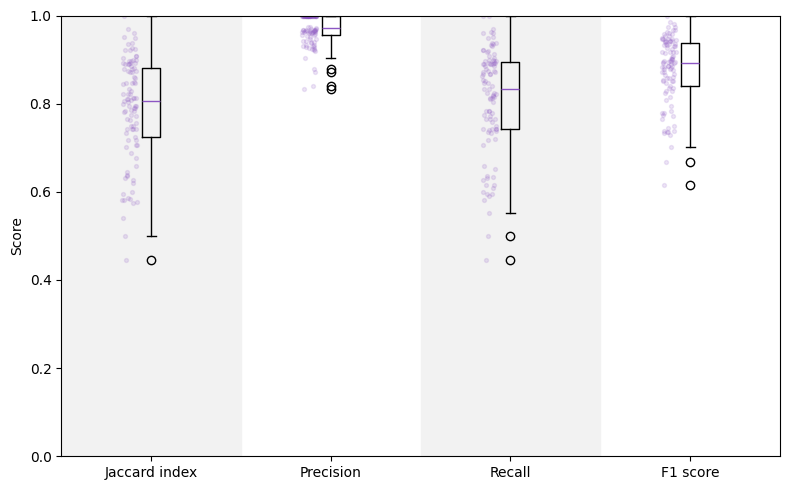

In [27]:
metrics = {
    "Jaccard index": [ji],
    "Precision": [precision],
    "Recall": [recall],
    "F1 score": [f1],
}

colors = ["#8c56c3ff"]
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(8, 5))

for m, values in enumerate(metrics.values()):
    for i, v in enumerate(values):
        ax.boxplot(
            v,
            positions=[m],
            widths=0.1,
            medianprops=dict(color=colors[i]),
        )

        x = m + rng.uniform(-0.04, 0.04, len(v))-0.12
        ax.scatter(x, v, s=8, alpha=0.15, color=colors[i])

for m in range(0, len(metrics), 2):
    ax.axvspan(m - 0.5, m + 0.5, color="0.95", zorder=0)

ax.set_xticks(range(len(metrics)), list(metrics))
ax.set_xlim(-0.5, len(metrics) - 0.5)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")

fig.tight_layout()

And printing the median values.

In [28]:
for name, values in metrics.items():
    print(f"{name:<15}{np.median(values):.3f}")

Jaccard index  0.807
Precision      0.973
Recall         0.833
F1 score       0.893


### 5.2 Visualization in 2D
The predictions and ground truth are compared as 2D maximum-intensity projections along the axial direction, providing an intuitive overview of localization accuracy in the image plane.

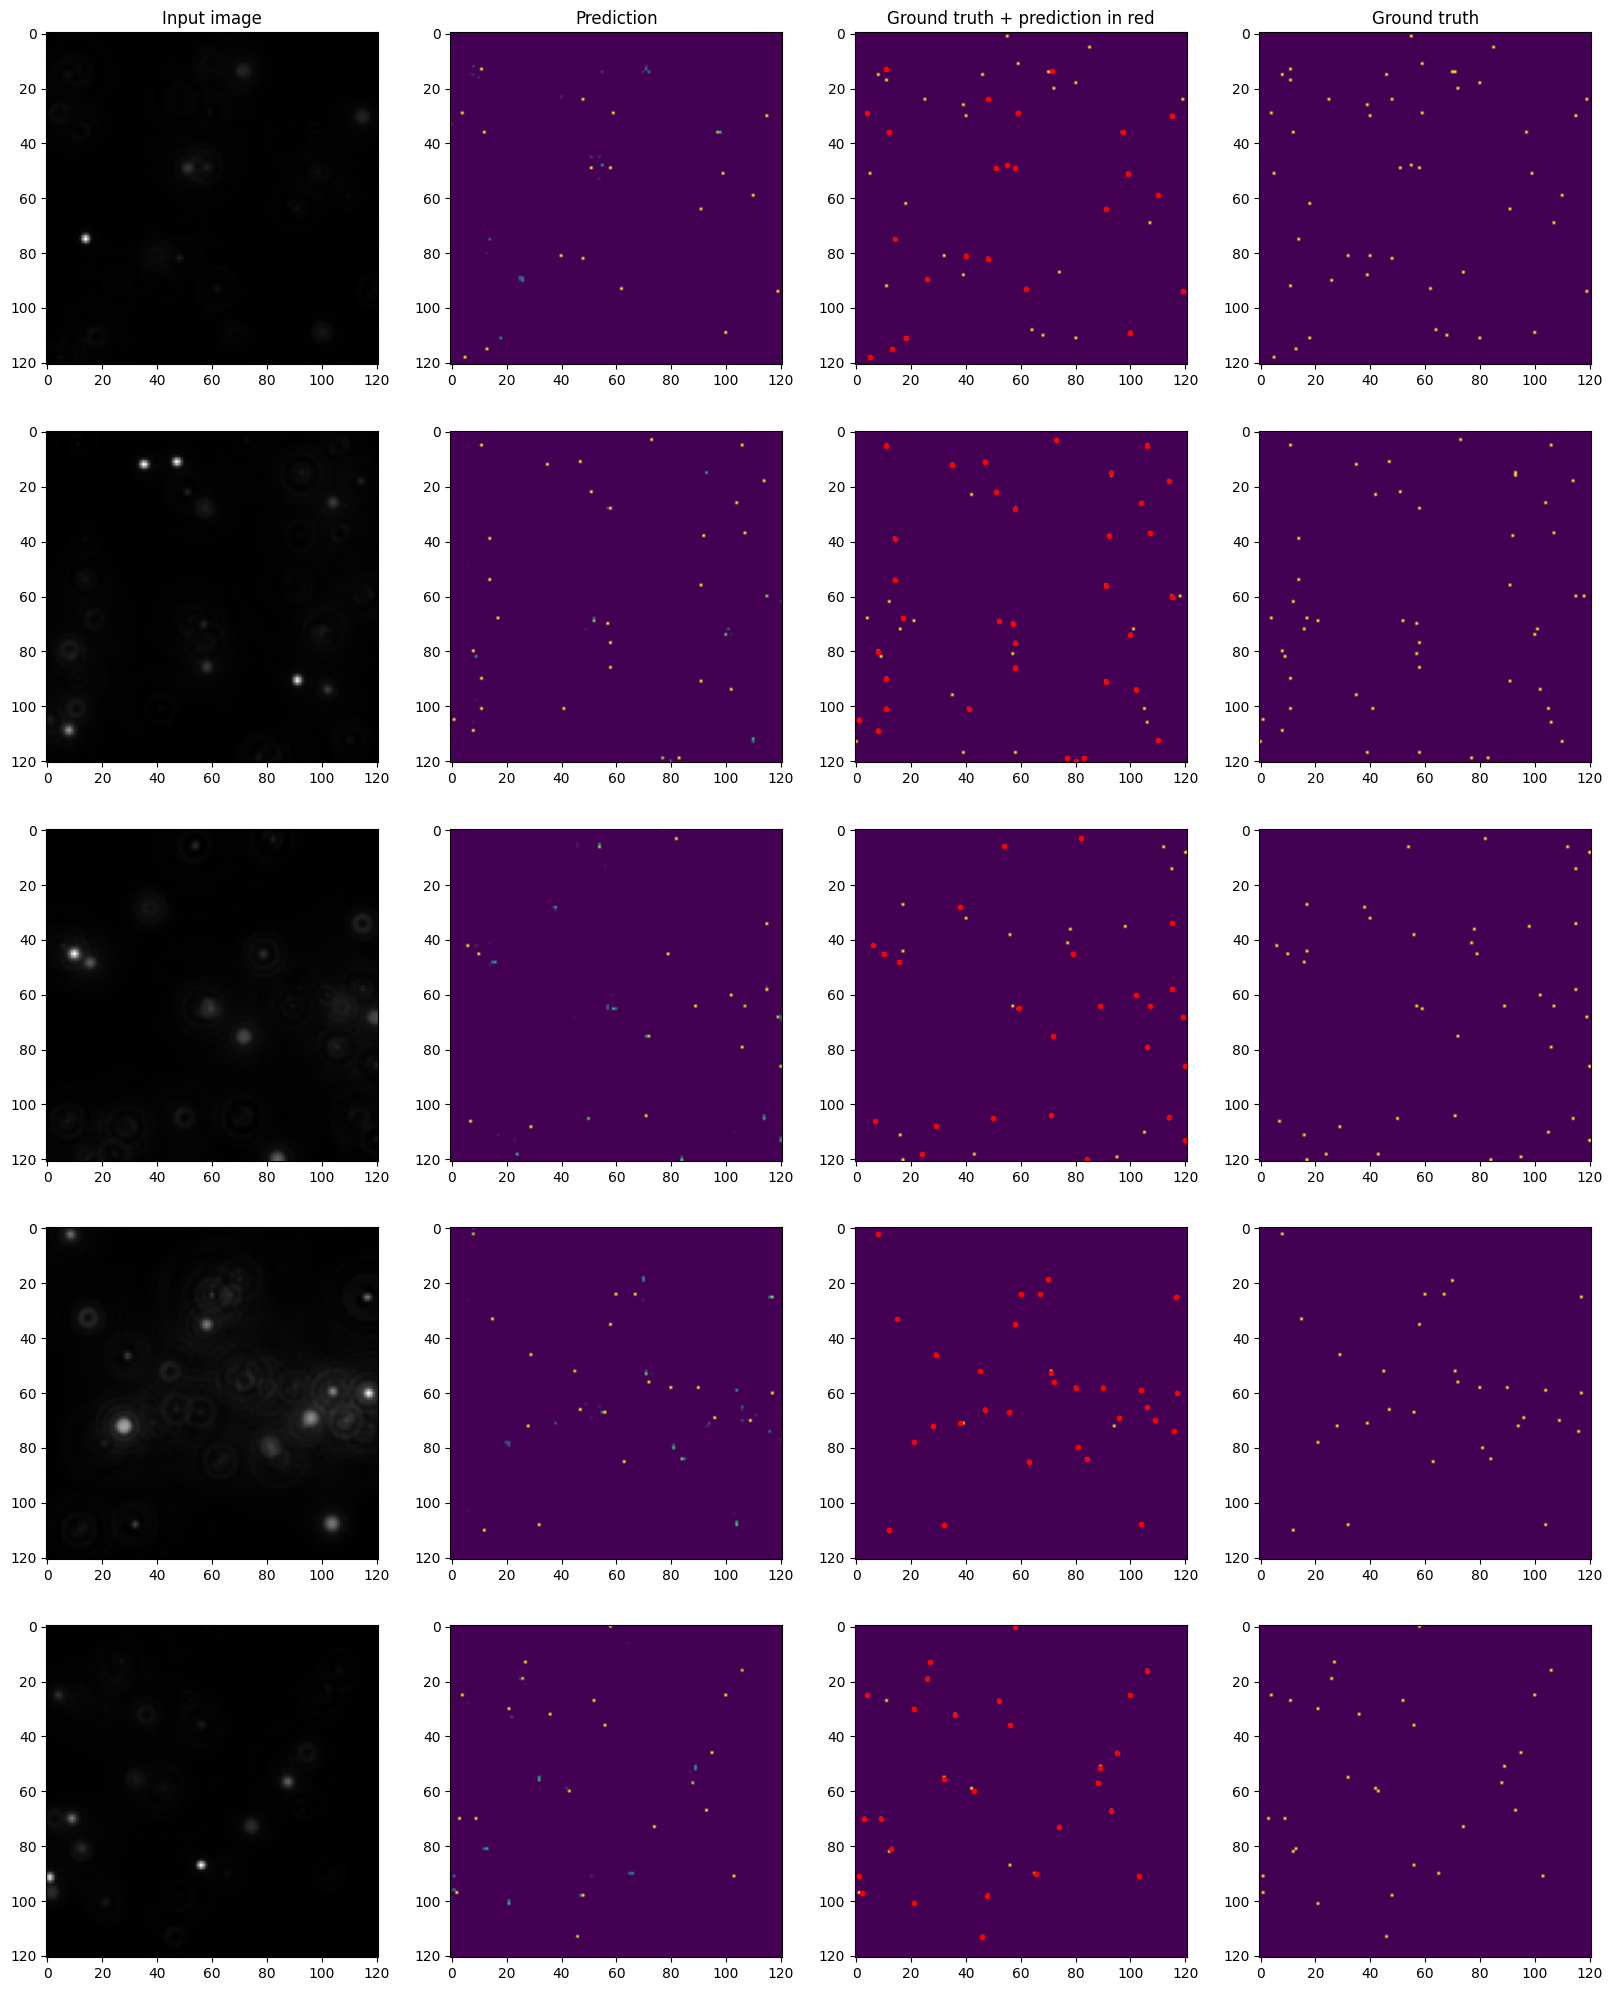

In [29]:
num_samples = 5
fig, ax = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))

images, gt, exact_pos = [], [], []
for _ in range(num_samples):
    pip.update()
    img, g = pip.resolve()
    pos = xyz.points
    images.append(img)
    gt.append(g)
    exact_pos.append(pos)

images = torch.stack(images)
gt = torch.stack(gt)

cnn.eval()
preds = cnn(images)

for i in range(num_samples):

    xyz_rec, conf_rec = postprocessing_module(preds[i])
    xyz_target = torch.nonzero(gt[i])[:, [2, 1, 0]]

    ax[i, 0].imshow(images[i, 0].cpu().detach().numpy(), cmap="gray")
    ax[i, 1].imshow(preds[i].max(dim=0)[0].cpu().detach().numpy())
    ax[i, 2].imshow(gt[i].max(dim=0)[0].cpu().detach().numpy())
    ax[i, 2].plot(xyz_rec[:, 0], xyz_rec[:, 1], c="red", marker=".", ls=" ")
    ax[i, 3].imshow(gt[i].max(dim=0)[0].cpu().detach().numpy())

ax[0, 0].set_title("Input image")
ax[0, 1].set_title("Prediction")
ax[0, 2].set_title("Ground truth + prediction in red")
ax[0, 3].set_title("Ground truth");

### 5.3 Visualization in 3D

Predicted and ground-truth particle coordinates are displayed in 3D to assess depth accuracy and separation in dense regions.

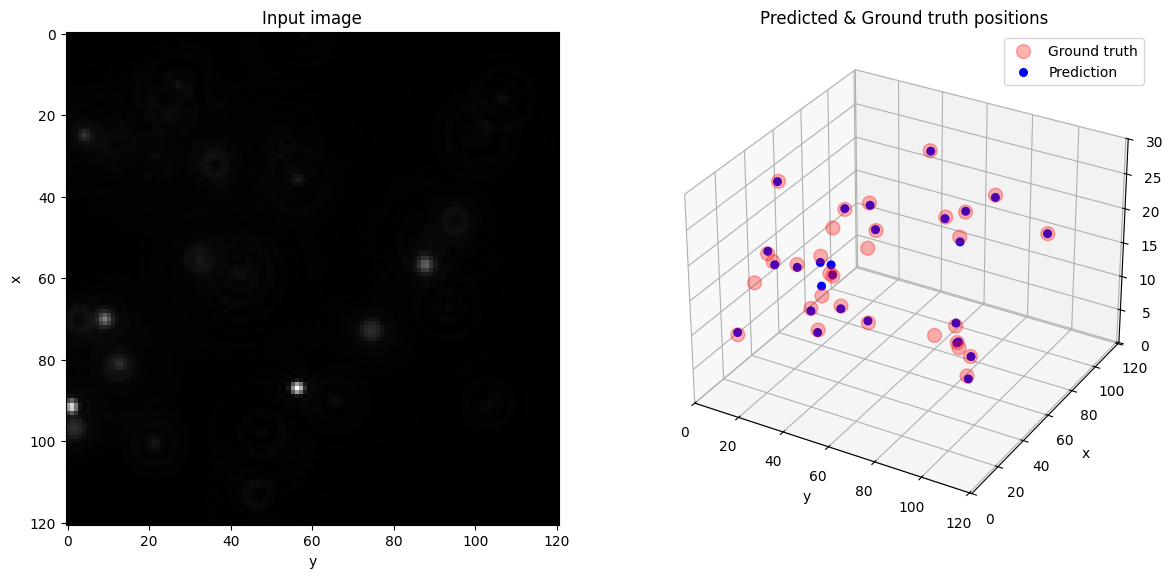

In [30]:
sample = 4

fig = plt.figure(figsize=(14, 7))

ax1 = fig.add_subplot(121)
ax1.imshow(images[sample, 0].cpu().detach().numpy(), cmap="gray")
ax1.set_xlabel("y")
ax1.set_ylabel("x")
ax1.set_title("Input image")


xyz_rec, conf_rec = postprocessing_module(preds[sample])
xyz_target = torch.nonzero(gt[sample])[:, [2, 1, 0]]

ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(
    exact_pos[sample][:, 1],
    exact_pos[sample][:, 0],
    exact_pos[sample][:, 2],
    c="red",
    marker="o",
    s=100,
    label="Ground truth",
    alpha=0.3,
)
ax2.scatter(
    xyz_rec[:, 0],
    xyz_rec[:, 1],
    xyz_rec[:, 2],
    c="blue",
    marker="o",
    s=30,
    label="Prediction",
    alpha=1,
)

ax2.set_xlabel("y")
ax2.set_ylabel("x")
ax2.set_zlabel("z")
ax2.set_xlim(0, image_size)
ax2.set_ylim(0, image_size)
ax2.set_zlim(0, depth)
ax2.set_title("Predicted & Ground truth positions")
ax2.legend();

## 6. Comparison without a trainable phase mask
To understand the effect of the trainable phase mask, an identical training and evaluation protocol is repeated with the phase mask removed.

### 6.1 Training without the phase mask
The optical model is instantiated without a pupil function, and a copy of the CNN is trained using the same optimizer, batch size, and number of epochs. The loss function remains unchanged. The post-processing threshold is slightly adjusted to achieve optimal performance in this configuration.

In [31]:
optics_no_phase_mask = dt.Fluorescence(
    NA=1.45,
    refractive_index_medium=1.33,
    output_region=(0, 0, image_size, image_size),
)

im_pip_no_phase_mask = (
    optics_no_phase_mask(particle ^ num_points)
    >> noise_poisson
    >> noise_gaussian
)

pip_no_phase_mask = (im_pip_no_phase_mask & gt_pip) >> dt.MoveAxis(2, 0)

In [32]:
cnn_no_phase_mask = CNN.create()
cnn_no_phase_mask.to(device)

optimizer_no_phase_mask = torch.optim.Adam(
    list(cnn_no_phase_mask.parameters()), lr=1e-3
)

In [33]:
loss_history = []

for epoch in range(num_epochs):
    cnn_no_phase_mask.train()

    images, gt = [], []
    for _ in range(batch_size):
        pip_no_phase_mask.update()
        img, g = pip_no_phase_mask.resolve()
        images.append(img)
        gt.append(g)

    images = torch.stack(images)
    gt = torch.stack(gt).to(device, dtype=torch.float32)

    optimizer_no_phase_mask.zero_grad(set_to_none=True)
    preds = cnn_no_phase_mask(images)
    loss = loss_fn(preds, gt)
    loss.backward()
    optimizer_no_phase_mask.step()

    loss_history.append(loss.detach().cpu().item())

    if (epoch % 50) == 0:
        print(f"Epoch {epoch}, Loss: {loss.detach().cpu().item():.4f}")

Epoch 0, Loss: 1.6308
Epoch 50, Loss: 0.8371
Epoch 100, Loss: 0.7440
Epoch 150, Loss: 0.6878
Epoch 200, Loss: 0.6254
Epoch 250, Loss: 0.5962
Epoch 300, Loss: 0.5859
Epoch 350, Loss: 0.5777
Epoch 400, Loss: 0.5746
Epoch 450, Loss: 0.5474
Epoch 500, Loss: 0.5413
Epoch 550, Loss: 0.5397
Epoch 600, Loss: 0.5429
Epoch 650, Loss: 0.5724
Epoch 700, Loss: 0.5146
Epoch 750, Loss: 0.5134
Epoch 800, Loss: 0.5171
Epoch 850, Loss: 0.5365
Epoch 900, Loss: 0.5095
Epoch 950, Loss: 0.4910


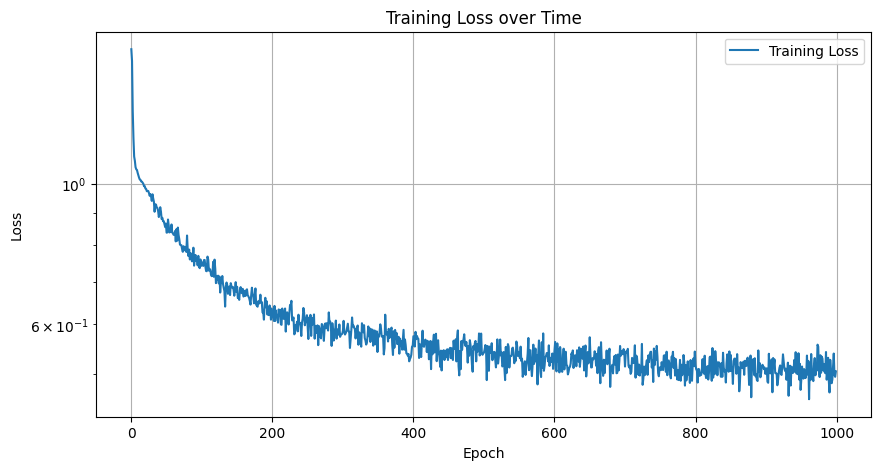

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(loss_history)), loss_history, label="Training Loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.grid(True)
plt.legend()
plt.show()

### 6.2 Performance evaluation
Performance is evaluated in the same manner as with the trainable phase mask, using the same number of test images and the same metrics.

In [35]:
ji_no_phase_mask = []
precision_no_phase_mask = []
recall_no_phase_mask = []
f1_no_phase_mask = []

cnn_no_phase_mask.eval()

for _ in range(num_tests):
    pip_no_phase_mask.update()
    img, g = pip_no_phase_mask.resolve()
    g = g.to(device)

    pred = cnn_no_phase_mask(img.unsqueeze(0))

    tp, fp, fn = count_matches(pred, g, postprocessing_module)

    jaccard_index, precision_score, recall_score, f1_score = detection_metrics(tp, fp, fn)

    ji_no_phase_mask.append(jaccard_index)
    precision_no_phase_mask.append(precision_score)
    recall_no_phase_mask.append(recall_score)
    f1_no_phase_mask.append(f1_score)

Plotting the detection metrics for both configurations, so that the effect of the trainable phase mask can be seen directly.

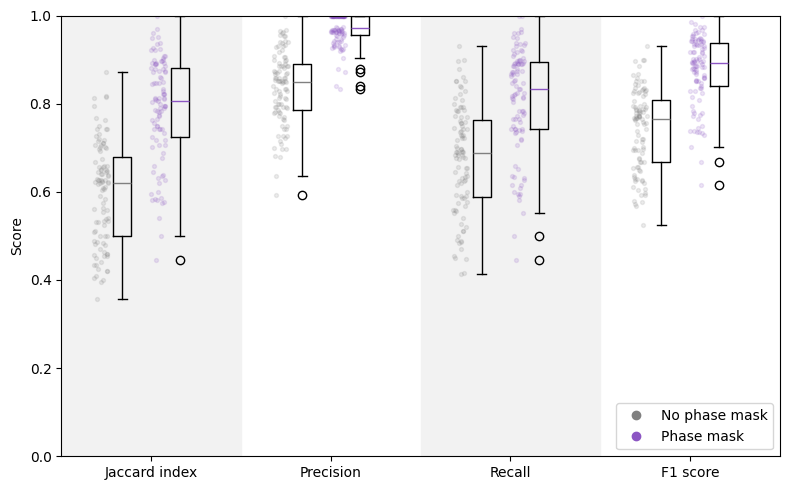

In [36]:
from matplotlib.lines import Line2D

metrics = {
    "Jaccard index": [ji_no_phase_mask, ji],
    "Precision": [precision_no_phase_mask, precision],
    "Recall": [recall_no_phase_mask, recall],
    "F1 score": [f1_no_phase_mask, f1],
}

labels = ["No phase mask", "Phase mask"]
colors = ["gray", "#8c56c3ff"]
offsets = [-0.16, 0.16]

rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(8, 5))

for m, values in enumerate(metrics.values()):
    for i, v in enumerate(values):
        ax.boxplot(
            v,
            positions=[m + offsets[i]],
            widths=0.1,
            medianprops=dict(color=colors[i]),
        )

        x = m + offsets[i] + rng.uniform(-0.04, 0.04, len(v))-0.12
        ax.scatter(x, v, s=8, alpha=0.15, color=colors[i])

for m in range(0, len(metrics), 2):
    ax.axvspan(m - 0.5, m + 0.5, color="0.95", zorder=0)


ax.set_xticks(range(len(metrics)), list(metrics))
ax.set_xlim(-0.5, len(metrics) - 0.5)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.legend(
    handles=[
        Line2D([], [], color=c, marker="o", ls="", ms=6, label=l)
        for c, l in zip(colors, labels)
    ],
    loc="lower right",
)

fig.tight_layout()

And comparing the median values.

In [40]:
print(f"{'':<15}{'No phase mask':>12}{'Phase mask':>15}")
for name, (with_mask, without_mask) in metrics.items():
    print(
        f"{name:<15}"
        f"{np.median(with_mask):>12.3f}"
        f"{np.median(without_mask):>15.3f}"
    )

               No phase mask     Phase mask
Jaccard index         0.620          0.807
Precision             0.850          0.973
Recall                0.689          0.833
F1 score              0.766          0.893


### 6.3 Visualization in 2D
The same maximum-intensity projections as in Section 5.2, now for the network trained without the phase mask.

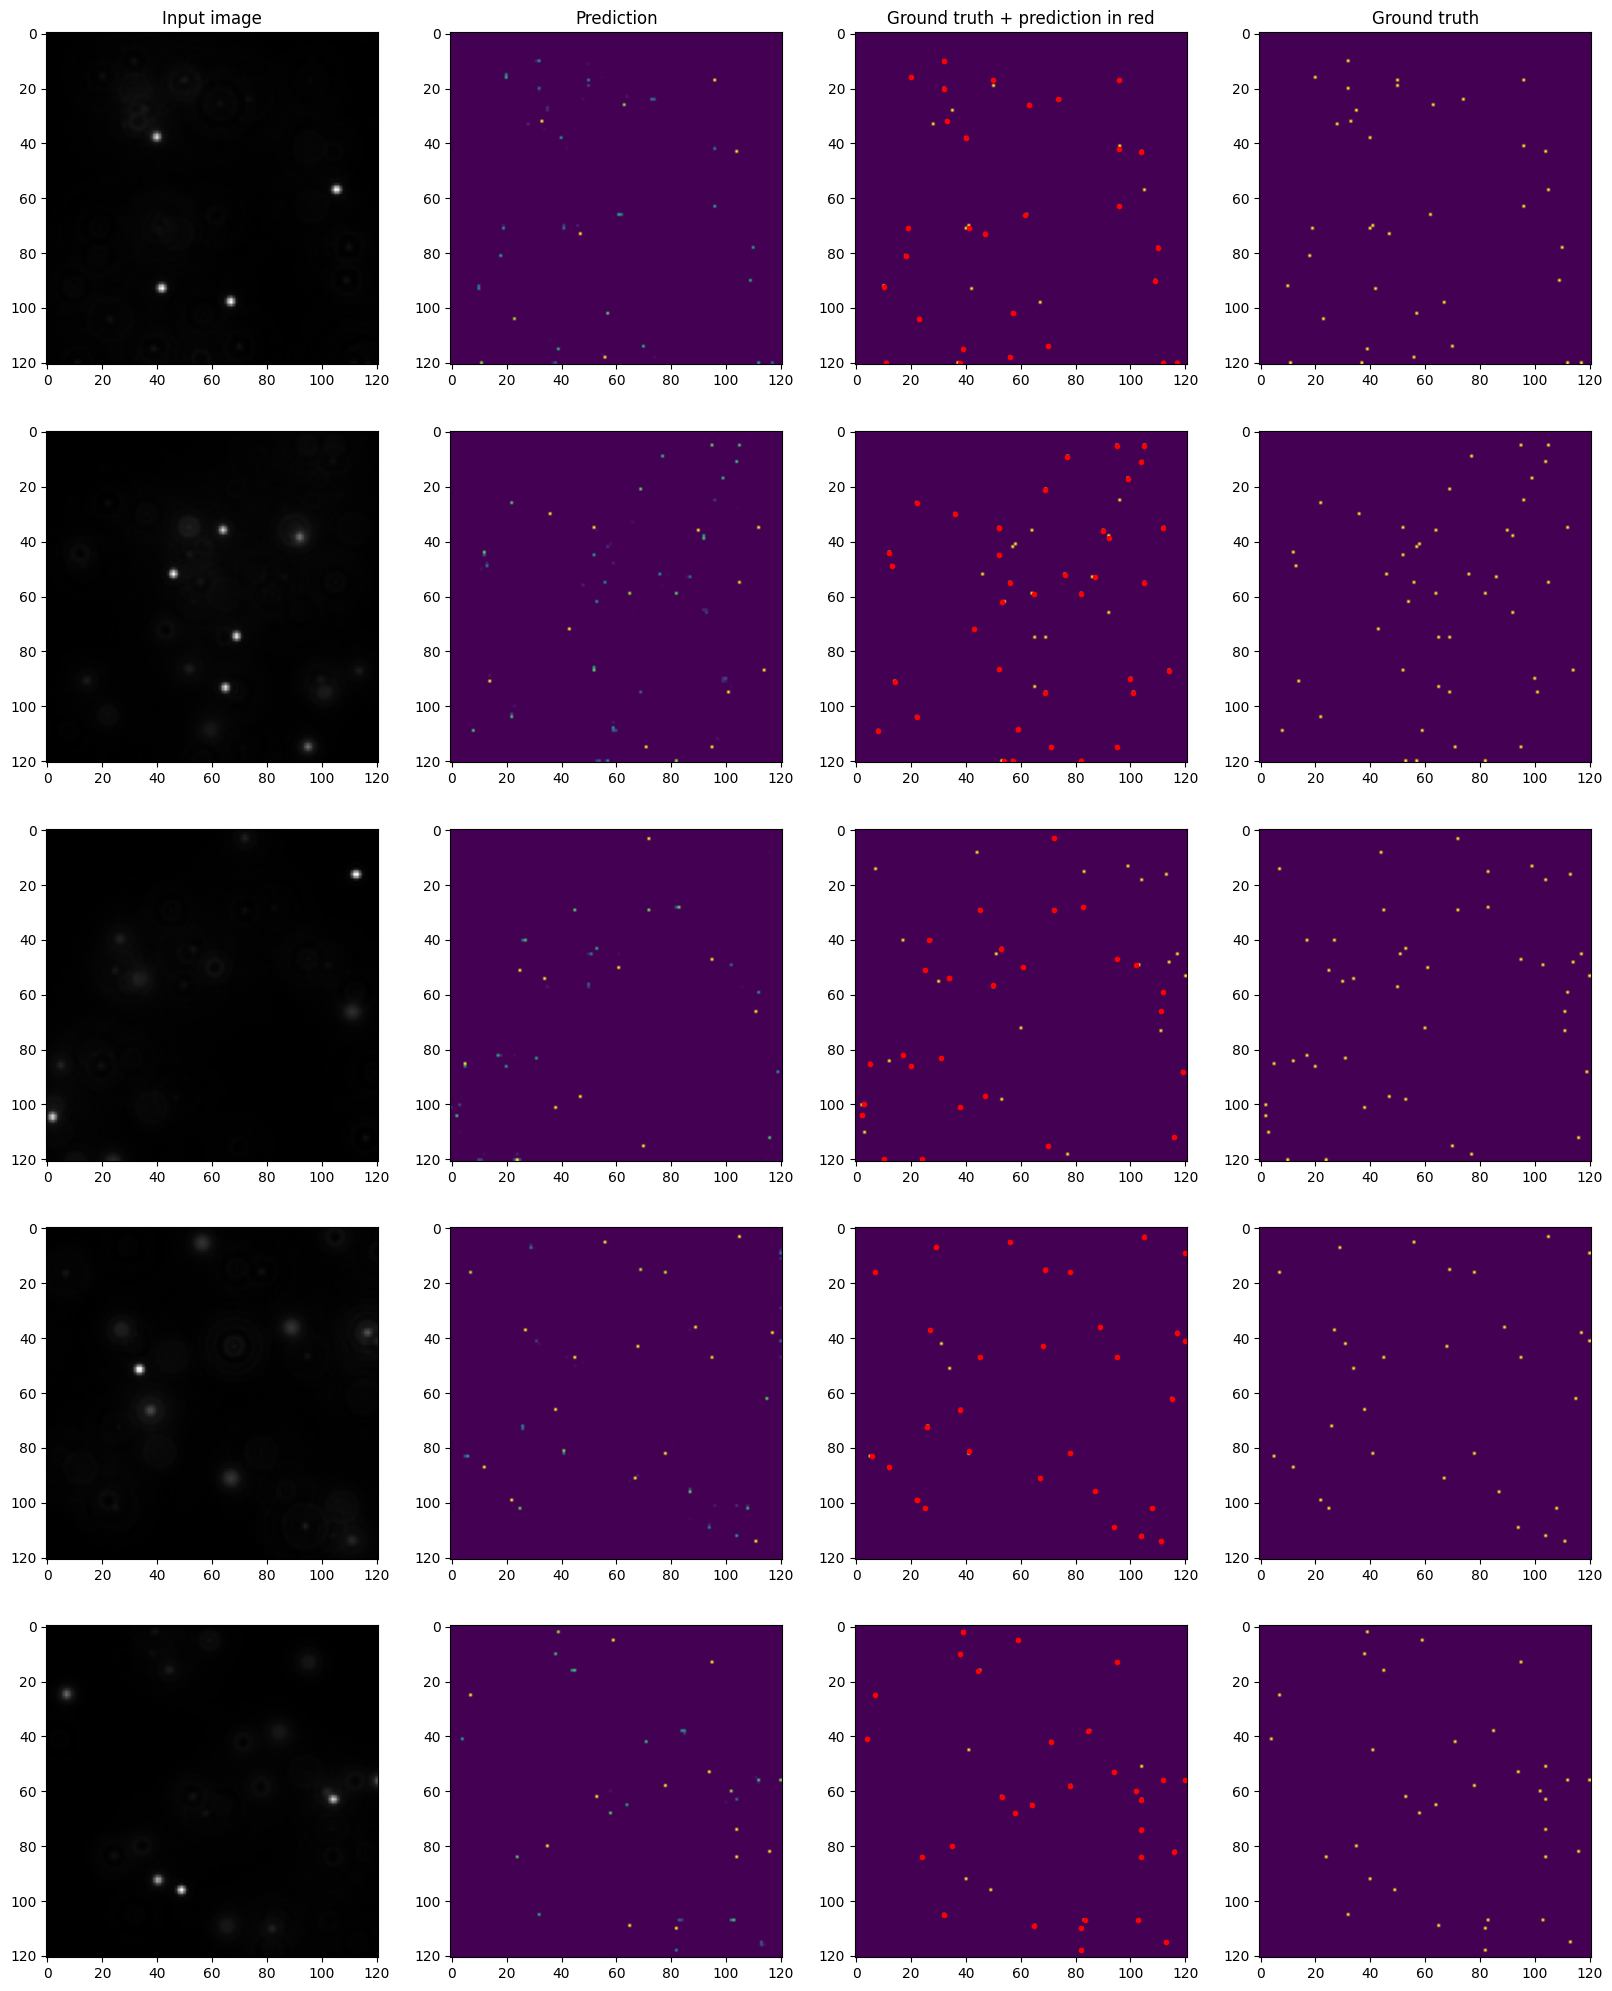

In [38]:
num_samples = 5
fig, ax = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))

images, gt = [], []
for _ in range(num_samples):
    pip_no_phase_mask.update()
    img, g = pip_no_phase_mask.resolve()
    images.append(img)
    gt.append(g)

images = torch.stack(images)
gt = torch.stack(gt)

cnn_no_phase_mask.eval()
preds = cnn_no_phase_mask(images)

for i in range(num_samples):

    xyz_rec, conf_rec = postprocessing_module(preds[i])

    xyz_target = torch.nonzero(gt[i])[:, [2, 1, 0]]

    ax[i, 0].imshow(images[i, 0].cpu().detach().numpy(), cmap="gray")
    ax[i, 1].imshow(preds[i].max(dim=0)[0].cpu().detach().numpy())
    ax[i, 2].imshow(gt[i].max(dim=0)[0].cpu().detach().numpy())
    ax[i, 2].plot(xyz_rec[:, 0], xyz_rec[:, 1], c="red", marker=".", ls=" ")
    ax[i, 3].imshow(gt[i].max(dim=0)[0].cpu().detach().numpy())

ax[0, 0].set_title("Input image")
ax[0, 1].set_title("Prediction")
ax[0, 2].set_title("Ground truth + prediction in red")
ax[0, 3].set_title("Ground truth");

### 6.4 Visualization in 3D
And the corresponding 3D view of the predicted and ground-truth positions.

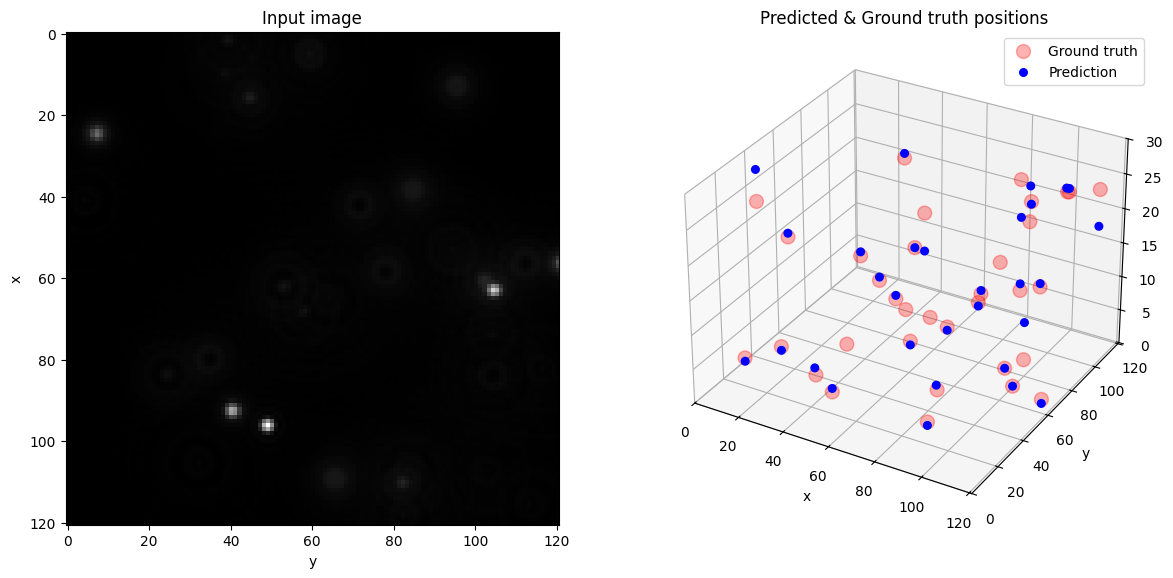

In [39]:
sample = 4

fig = plt.figure(figsize=(14, 7))

ax1 = fig.add_subplot(121)
ax1.imshow(images[sample, 0].cpu().detach().numpy(), cmap="gray")
ax1.set_xlabel("y")
ax1.set_ylabel("x")
ax1.set_title("Input image")


xyz_rec, conf_rec = postprocessing_module(preds[sample])
xyz_target = torch.nonzero(gt[sample])[:, [2, 1, 0]]

ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(
    xyz_target[:, 0],
    xyz_target[:, 1],
    xyz_target[:, 2],
    c="red",
    marker="o",
    s=100,
    label="Ground truth",
    alpha=0.3,
)
ax2.scatter(
    xyz_rec[:, 0],
    xyz_rec[:, 1],
    xyz_rec[:, 2],
    c="blue",
    marker="o",
    s=30,
    label="Prediction",
    alpha=1,
)

ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
ax2.set_xlim(0, image_size)
ax2.set_ylim(0, image_size)
ax2.set_zlim(0, depth)
ax2.set_title("Predicted & Ground truth positions")
ax2.legend();